# VA-π Mini — Giai đoạn 3: VA-π RL Fine-tuning + Evaluation

Đáp ứng yêu cầu rubric:
> **Evaluation**: Fine-tuning the trained model (Implement=Mini) for testing on at least 2 novel dataset

Notebook này:
1. Load checkpoint `vqvae_mini.pt` + `gpt_mini.pt` từ Giai đoạn 1-2 (Implement: Mini)
2. Áp **VA-π RL fine-tuning** (GRPO + pixel-reward + corruption kernel + NTP regularization) trên **CIFAR-100** (dataset mới #1)
3. Áp VA-π RL fine-tuning **riêng** trên **STL-10** (dataset mới #2)
4. Đánh giá **trước/sau VA-π** trên mỗi dataset (FID/IS xấp xỉ + ảnh sample) để thấy rõ tác động của VA-π

**Trước khi chạy:** sửa `CODE_DATASET_DIR` và `CKPT_DATASET_DIR` ở Cell 2 cho khớp với Kaggle Dataset của bạn (giống Giai đoạn 2).

## 1. Cài đặt & import

In [1]:
!pip install torch torchvision scipy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incom

In [2]:
import os
import sys
import shutil
import glob

# === TỰ ĐỘNG TÌM KIẾM ĐƯỜNG DẪN CODE VÀ CHECKPOINT TRÊN KAGGLE ===
vapi_mini_paths = glob.glob('/kaggle/input/**/vapi_mini', recursive=True)
CODE_DATASET_DIR = os.path.dirname(vapi_mini_paths[0]) if vapi_mini_paths else "/kaggle/input/datasets/caosfourn/va-pi-3"

ckpt_candidates = glob.glob('/kaggle/**/vqvae_mini.pt', recursive=True)
if ckpt_candidates:
    parent_dir = os.path.dirname(ckpt_candidates[0])
    CKPT_DATASET_DIR = os.path.dirname(parent_dir) if os.path.basename(parent_dir) == "checkpoints" else parent_dir
else:
    CKPT_DATASET_DIR = "/kaggle/input/notebooks/caosfourn/va-pi-gd1"

WORK_DIR = "/kaggle/working/vapi_mini"
OUT_CKPT_DIR = "/kaggle/working/checkpoints_vapi"

# Copy code sang working để import được bình thường
if not os.path.exists(WORK_DIR):
    zip_candidates = [f for f in os.listdir(CODE_DATASET_DIR) if f.endswith(".zip")] if os.path.exists(CODE_DATASET_DIR) else []
    if zip_candidates:
        import zipfile
        with zipfile.ZipFile(os.path.join(CODE_DATASET_DIR, zip_candidates[0])) as z:
            z.extractall("/kaggle/working/")
    else:
        shutil.copytree(os.path.join(CODE_DATASET_DIR, "vapi_mini"), WORK_DIR)

sys.path.append(WORK_DIR)
os.chdir(WORK_DIR)
os.makedirs(OUT_CKPT_DIR, exist_ok=True)
print("Working dir:", os.getcwd())
print("Nội dung:", os.listdir(WORK_DIR))

Working dir: /kaggle/working/vapi_mini
Nội dung: ['notebooks', 'data', 'README.md', 'scripts', 'models']


In [3]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

import scripts.train_vapi as tv
from scripts.eval_utils import (
    sample_and_decode, denormalize, get_inception_features,
    compute_fid, compute_inception_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

VQVAE_CKPT = os.path.join(CKPT_DATASET_DIR, "checkpoints", "vqvae_mini.pt")
GPT_CKPT = os.path.join(CKPT_DATASET_DIR, "checkpoints", "gpt_mini.pt")
print(os.listdir(CKPT_DATASET_DIR))

Device: cuda
['checkpoints', '__results__.html', 'vapi_mini', '__notebook__.ipynb', '__output__.json', 'data', 'custom.css']


## 2. Cấu hình tham số VA-π

Theo Table 7 của paper gốc: `lr=1e-6`, `beta=0.1` (KL coeff), `G=8` (group size), `xi=0.5` (corruption ratio tối đa). Vì model Mini rất nhỏ và batch size cũng nhỏ hơn nhiều so với paper gốc (8×A100), `lr=1e-6` có thể QUÁ NHỎ để thấy thay đổi rõ trong vài trăm step — notebook này dùng `lr` lớn hơn (`1e-4`) làm mặc định để bạn thấy được hiệu ứng rõ ràng hơn trong thời gian giới hạn của Kaggle. Bạn có thể đổi lại `1e-6` nếu muốn trung thành tuyệt đối với paper (nhưng cần tăng `steps` lên rất nhiều).

**Lưu ý về `inner_epochs`:** đây là số lần gradient-update trên CÙNG một rollout (giống PPO `ppo_epochs`) trước khi lấy rollout mới. Nếu để `inner_epochs=1`, phần `clip_loss`/`kl_loss` sẽ luôn ≈0 (vì `new_logits` trùng `old_logits` ngay sau sample) — đây là lý do bắt buộc phải >1.

In [4]:
class VAPiArgs:
    vqvae_ckpt = VQVAE_CKPT
    gpt_ckpt = GPT_CKPT
    data_root = "/kaggle/working/data"
    ckpt_dir = OUT_CKPT_DIR

    group_size = 8            # G (Table 7)
    num_conditions_per_batch = 8
    corrupt_min_ratio = 0.1
    corrupt_max_ratio = 0.5    # xi (Table 7)
    beta = 0.1                 # KL coeff (Table 7)
    lambda_ntp = 1.0
    clip_eps = 0.2
    reward_mode = "gaussian"
    reward_tau = 0.5

    steps = 300                # tăng lên nếu còn quota GPU (paper: rất ít step vẫn hiệu quả)
    inner_epochs = 4
    lr = 1e-6                 # xem chú thích ở trên; đổi thành 1e-6 nếu muốn đúng paper
    log_every = 10
    save_every = 50
    device = "cuda" if torch.cuda.is_available() else "cpu"

print("Cấu hình VA-π đã sẵn sàng.")

Cấu hình VA-π đã sẵn sàng.


## 3. Đánh giá BASELINE (trước VA-π) trên 2 dataset mới

Trước khi fine-tune, ta cần biết model Mini (chưa qua VA-π) hoạt động thế nào trên CIFAR-100/STL-10 — để so sánh công bằng "trước vs sau" trên cùng dataset mới (khác với baseline Giai đoạn 2 vốn đo trên CIFAR-10 — dataset ĐÃ train, không phải dataset mới).

In [5]:
def evaluate_on_dataset(vqvae, gpt, loader, num_classes_novel, num_classes_train, device, n_eval=500, label=""):
    """Đánh giá FID/IS xấp xỉ của (vqvae, gpt) trên 1 dataloader, dùng class label
    đã remap về không gian class đã train (modulo)."""
    real_images, real_labels = [], []
    for imgs, labels in loader:
        real_images.append(imgs)
        real_labels.append(labels)
        if sum(x.shape[0] for x in real_images) >= n_eval:
            break
    real_images = torch.cat(real_images)[:n_eval]
    real_labels = torch.cat(real_labels)[:n_eval]
    real_images_01 = denormalize(real_images)

    mapped_labels = tv.remap_labels(real_labels, num_classes_novel, num_classes_train)

    fake_images_01 = []
    bs = 64
    for i in range(0, n_eval, bs):
        lb = mapped_labels[i:i+bs]
        imgs = sample_and_decode(vqvae, gpt, lb, device, temperature=1.0, top_k=50)
        fake_images_01.append(imgs.cpu())
    fake_images_01 = torch.cat(fake_images_01)[:n_eval]

    real_feats = get_inception_features(real_images_01, device)
    fake_feats = get_inception_features(fake_images_01, device)
    fid = compute_fid(real_feats, fake_feats)
    is_mean, is_std = compute_inception_score(fake_images_01, device)

    print(f"[{label}] FID={fid:.2f}  IS={is_mean:.2f}±{is_std:.2f}  (N={n_eval})")
    return {"fid": fid, "is_mean": is_mean, "is_std": is_std,
            "real_images_01": real_images_01, "fake_images_01": fake_images_01,
            "real_labels": real_labels}

In [6]:
from data.data_utils import get_cifar100_loaders, get_stl10_loaders

vqvae_base, _ = tv.load_frozen_vqvae(VQVAE_CKPT, device)
gpt_base, seq_len, num_classes_train, gpt_args = tv.load_gpt_policy(GPT_CKPT, device)
gpt_base.eval()

cifar100_loader, num_classes_c100 = get_cifar100_loaders(root="/kaggle/working/data", image_size=32, batch_size=128)
stl10_loader, num_classes_stl = get_stl10_loaders(root="/kaggle/working/data", image_size=32, batch_size=128)

print("\n=== BASELINE (trước VA-π) ===")
baseline_c100 = evaluate_on_dataset(vqvae_base, gpt_base, cifar100_loader, num_classes_c100, num_classes_train, device, n_eval=500, label="CIFAR-100 (trước VA-π)")
baseline_stl = evaluate_on_dataset(vqvae_base, gpt_base, stl10_loader, num_classes_stl, num_classes_train, device, n_eval=500, label="STL-10 (trước VA-π)")

100%|██████████| 169M/169M [00:45<00:00, 3.72MB/s]
100%|██████████| 2.64G/2.64G [06:59<00:00, 6.30MB/s]



=== BASELINE (trước VA-π) ===
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 219MB/s] 


[CIFAR-100 (trước VA-π)] FID=149.87  IS=2.90±0.14  (N=500)
[STL-10 (trước VA-π)] FID=139.20  IS=2.85±0.08  (N=500)


## 4. VA-π RL Fine-tuning trên CIFAR-100 (dataset mới #1)

In [7]:
args_c100 = VAPiArgs()
args_c100.dataset = "cifar100"

tv.train_vapi(args_c100)

Device: cuda
=== VA-π RL fine-tuning trên dataset MỚI: cifar100 ===
Đã load VQVAE (frozen) và GPT policy. seq_len=64, num_classes (lúc train Mini)=10
Dataset mới 'cifar100': 10000 ảnh, 100 class (map về 10 class đã train qua modulo)
[cifar100] step 10/300 loss=3.1779 clip=-0.0307 kl=0.0226 ntp=3.2063 reward=0.6147 (6s)
[cifar100] step 20/300 loss=2.4933 clip=-0.0298 kl=0.0519 ntp=2.5179 reward=0.7132 (11s)
[cifar100] step 30/300 loss=2.6563 clip=-0.0270 kl=0.1340 ntp=2.6699 reward=0.5743 (17s)
[cifar100] step 40/300 loss=3.0775 clip=-0.0286 kl=0.2006 ntp=3.0860 reward=0.6552 (22s)
[cifar100] step 50/300 loss=3.1142 clip=-0.0297 kl=0.3873 ntp=3.1052 reward=0.6126 (28s)
[cifar100] step 60/300 loss=2.9005 clip=-0.0270 kl=0.4647 ntp=2.8810 reward=0.6661 (33s)
[cifar100] step 70/300 loss=2.8808 clip=-0.0316 kl=0.4917 ntp=2.8633 reward=0.6998 (39s)
[cifar100] step 80/300 loss=3.3127 clip=-0.0268 kl=0.5865 ntp=3.2808 reward=0.6519 (44s)
[cifar100] step 90/300 loss=3.0635 clip=-0.0255 kl=0.813

## 5. VA-π RL Fine-tuning trên STL-10 (dataset mới #2)

In [8]:
args_stl = VAPiArgs()
args_stl.dataset = "stl10"

tv.train_vapi(args_stl)

Device: cuda
=== VA-π RL fine-tuning trên dataset MỚI: stl10 ===
Đã load VQVAE (frozen) và GPT policy. seq_len=64, num_classes (lúc train Mini)=10
Dataset mới 'stl10': 8000 ảnh, 10 class (map về 10 class đã train qua modulo)
[stl10] step 10/300 loss=3.0865 clip=-0.0310 kl=0.0364 ntp=3.1138 reward=0.5894 (5s)
[stl10] step 20/300 loss=3.1341 clip=-0.0342 kl=0.1531 ntp=3.1530 reward=0.6547 (10s)
[stl10] step 30/300 loss=3.2055 clip=-0.0341 kl=0.2209 ntp=3.2175 reward=0.6716 (15s)
[stl10] step 40/300 loss=2.7497 clip=-0.0314 kl=0.3448 ntp=2.7466 reward=0.6915 (21s)
[stl10] step 50/300 loss=3.1277 clip=-0.0299 kl=0.5613 ntp=3.1015 reward=0.6406 (26s)
[stl10] step 60/300 loss=3.2760 clip=-0.0286 kl=0.5764 ntp=3.2470 reward=0.6988 (31s)
[stl10] step 70/300 loss=3.4503 clip=-0.0235 kl=1.4115 ntp=3.3327 reward=0.6580 (37s)
[stl10] step 80/300 loss=2.9088 clip=-0.0322 kl=0.7465 ntp=2.8664 reward=0.6774 (42s)
[stl10] step 90/300 loss=3.4812 clip=-0.0289 kl=1.1394 ntp=3.3962 reward=0.6396 (47s)
[s

## 6. Đánh giá SAU VA-π trên cả 2 dataset (so sánh trực tiếp với baseline)

In [9]:
gpt_after_c100, _, _, _ = tv.load_gpt_policy(os.path.join(OUT_CKPT_DIR, "gpt_vapi_cifar100.pt"), device)
gpt_after_c100.eval()

gpt_after_stl, _, _, _ = tv.load_gpt_policy(os.path.join(OUT_CKPT_DIR, "gpt_vapi_stl10.pt"), device)
gpt_after_stl.eval()

print("\n=== SAU VA-π ===")
after_c100 = evaluate_on_dataset(vqvae_base, gpt_after_c100, cifar100_loader, num_classes_c100, num_classes_train, device, n_eval=500, label="CIFAR-100 (sau VA-π)")
after_stl = evaluate_on_dataset(vqvae_base, gpt_after_stl, stl10_loader, num_classes_stl, num_classes_train, device, n_eval=500, label="STL-10 (sau VA-π)")


=== SAU VA-π ===
[CIFAR-100 (sau VA-π)] FID=157.01  IS=2.53±0.18  (N=500)
[STL-10 (sau VA-π)] FID=150.35  IS=2.61±0.06  (N=500)


## 7. Bảng so sánh tổng hợp + biểu đồ

In [10]:
summary = {
    "CIFAR-100": {
        "FID trước": baseline_c100["fid"], "FID sau": after_c100["fid"],
        "IS trước": baseline_c100["is_mean"], "IS sau": after_c100["is_mean"],
    },
    "STL-10": {
        "FID trước": baseline_stl["fid"], "FID sau": after_stl["fid"],
        "IS trước": baseline_stl["is_mean"], "IS sau": after_stl["is_mean"],
    },
}

print("="*70)
print(f"{'Dataset':<12} {'FID trước':>10} {'FID sau':>10} {'IS trước':>10} {'IS sau':>10}")
print("="*70)
for name, m in summary.items():
    print(f"{name:<12} {m['FID trước']:>10.2f} {m['FID sau']:>10.2f} {m['IS trước']:>10.2f} {m['IS sau']:>10.2f}")
print("="*70)
print("(FID thấp hơn = tốt hơn; IS cao hơn = tốt hơn)")

with open("/kaggle/working/vapi_comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print("\nĐã lưu: /kaggle/working/vapi_comparison_summary.json")

Dataset       FID trước    FID sau   IS trước     IS sau
CIFAR-100        149.87     157.01       2.90       2.53
STL-10           139.20     150.35       2.85       2.61
(FID thấp hơn = tốt hơn; IS cao hơn = tốt hơn)

Đã lưu: /kaggle/working/vapi_comparison_summary.json


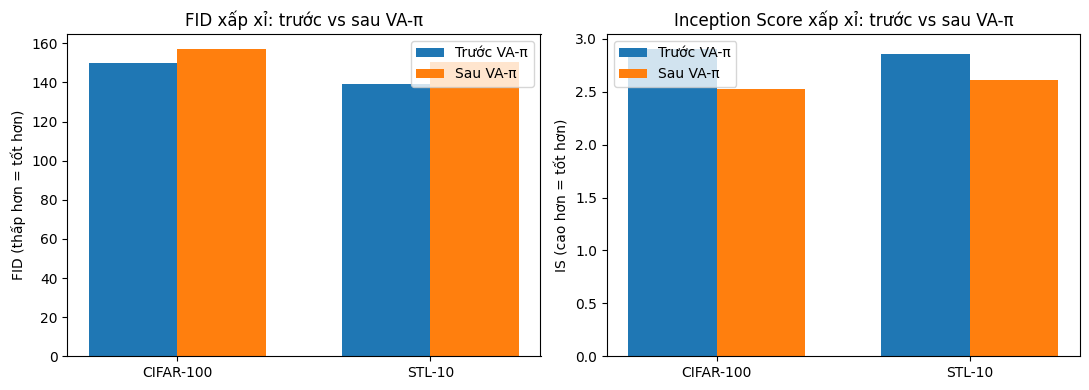

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
datasets = list(summary.keys())
fid_before = [summary[d]["FID trước"] for d in datasets]
fid_after = [summary[d]["FID sau"] for d in datasets]
is_before = [summary[d]["IS trước"] for d in datasets]
is_after = [summary[d]["IS sau"] for d in datasets]

x = np.arange(len(datasets))
w = 0.35

axes[0].bar(x - w/2, fid_before, w, label="Trước VA-π")
axes[0].bar(x + w/2, fid_after, w, label="Sau VA-π")
axes[0].set_xticks(x); axes[0].set_xticklabels(datasets)
axes[0].set_ylabel("FID (thấp hơn = tốt hơn)")
axes[0].set_title("FID xấp xỉ: trước vs sau VA-π")
axes[0].legend()

axes[1].bar(x - w/2, is_before, w, label="Trước VA-π")
axes[1].bar(x + w/2, is_after, w, label="Sau VA-π")
axes[1].set_xticks(x); axes[1].set_xticklabels(datasets)
axes[1].set_ylabel("IS (cao hơn = tốt hơn)")
axes[1].set_title("Inception Score xấp xỉ: trước vs sau VA-π")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/vapi_comparison_chart.png", dpi=120)
plt.show()

## 8. Trực quan ảnh: trước vs sau VA-π (CIFAR-100)

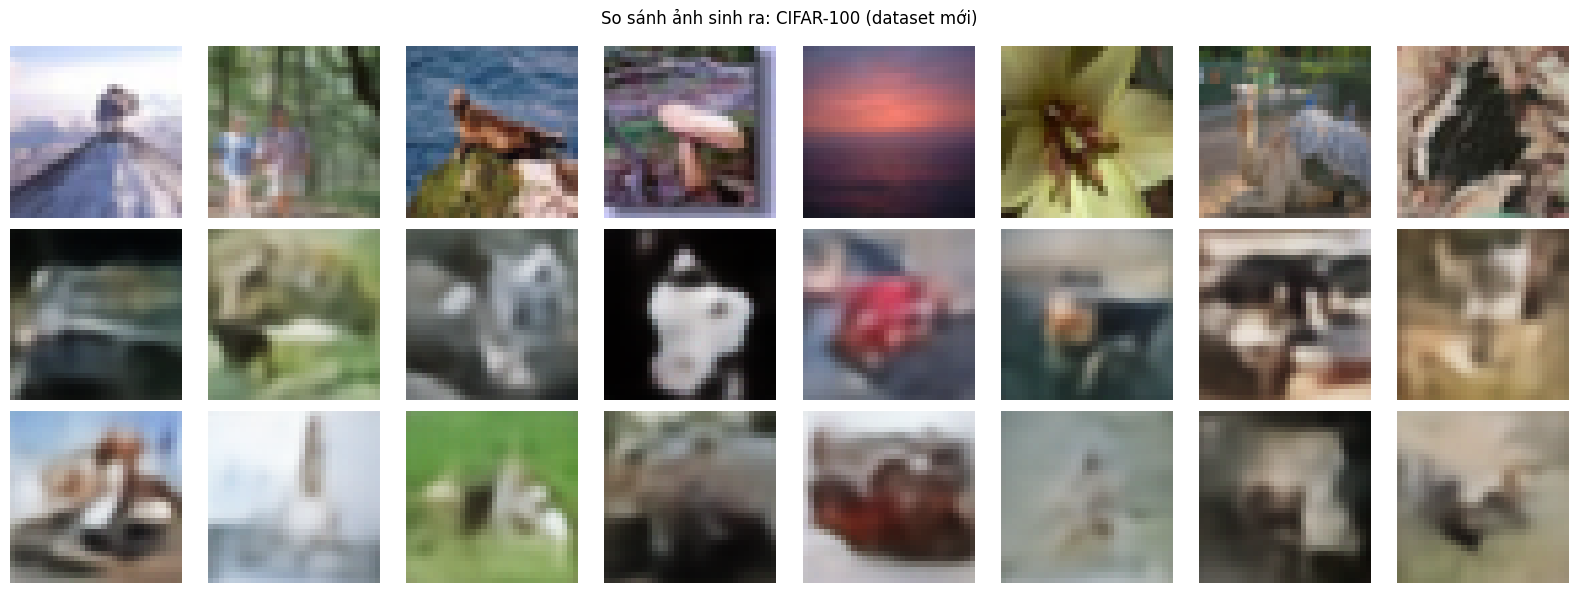

In [12]:
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(2*n_show, 6))

real_disp = baseline_c100["real_images_01"][:n_show]
before_disp = baseline_c100["fake_images_01"][:n_show]
after_disp = after_c100["fake_images_01"][:n_show]

for i in range(n_show):
    axes[0, i].imshow(real_disp[i].permute(1, 2, 0).numpy()); axes[0, i].axis("off")
    axes[1, i].imshow(before_disp[i].permute(1, 2, 0).numpy()); axes[1, i].axis("off")
    axes[2, i].imshow(after_disp[i].permute(1, 2, 0).numpy()); axes[2, i].axis("off")

axes[0, 0].set_ylabel("Ảnh thật\n(CIFAR-100)", fontsize=10)
axes[1, 0].set_ylabel("Trước VA-π", fontsize=10)
axes[2, 0].set_ylabel("Sau VA-π", fontsize=10)
plt.suptitle("So sánh ảnh sinh ra: CIFAR-100 (dataset mới)")
plt.tight_layout()
plt.savefig("/kaggle/working/vapi_before_after_cifar100.png", dpi=120)
plt.show()

## 9. Trực quan ảnh: trước vs sau VA-π (STL-10)

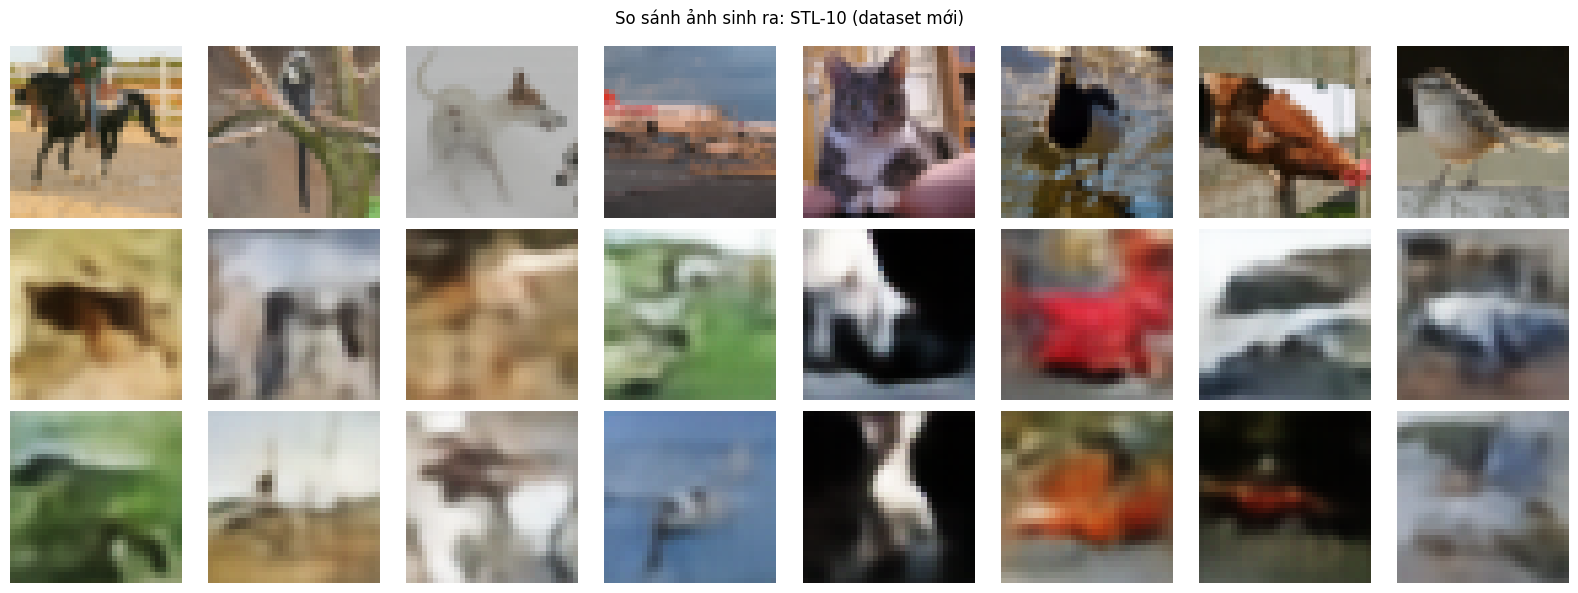

In [13]:
fig, axes = plt.subplots(3, n_show, figsize=(2*n_show, 6))

real_disp = baseline_stl["real_images_01"][:n_show]
before_disp = baseline_stl["fake_images_01"][:n_show]
after_disp = after_stl["fake_images_01"][:n_show]

for i in range(n_show):
    axes[0, i].imshow(real_disp[i].permute(1, 2, 0).numpy()); axes[0, i].axis("off")
    axes[1, i].imshow(before_disp[i].permute(1, 2, 0).numpy()); axes[1, i].axis("off")
    axes[2, i].imshow(after_disp[i].permute(1, 2, 0).numpy()); axes[2, i].axis("off")

axes[0, 0].set_ylabel("Ảnh thật\n(STL-10)", fontsize=10)
axes[1, 0].set_ylabel("Trước VA-π", fontsize=10)
axes[2, 0].set_ylabel("Sau VA-π", fontsize=10)
plt.suptitle("So sánh ảnh sinh ra: STL-10 (dataset mới)")
plt.tight_layout()
plt.savefig("/kaggle/working/vapi_before_after_stl10.png", dpi=120)
plt.show()

## 10. Biểu đồ training curve (loss + reward theo step)

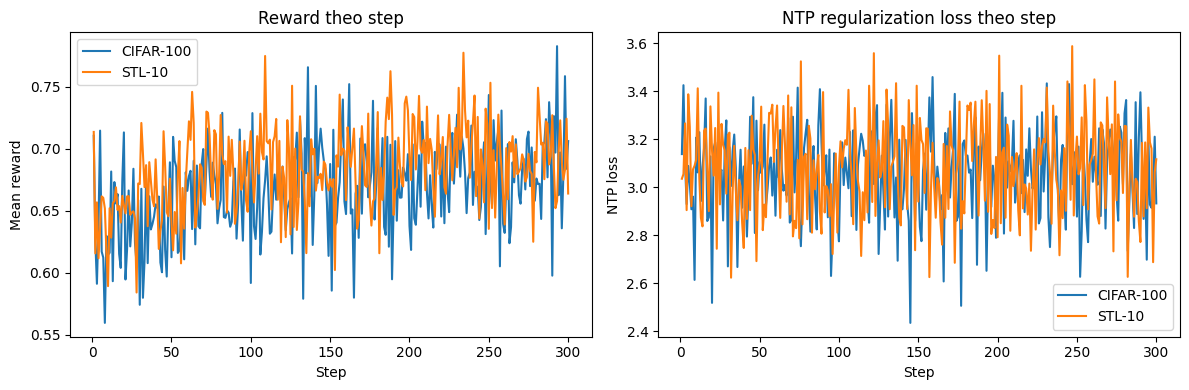

In [14]:
with open(os.path.join(OUT_CKPT_DIR, "vapi_history_cifar100.json")) as f:
    hist_c100 = json.load(f)
with open(os.path.join(OUT_CKPT_DIR, "vapi_history_stl10.json")) as f:
    hist_stl = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name in [(hist_c100, "CIFAR-100"), (hist_stl, "STL-10")]:
    steps = [h["step"] for h in hist]
    rewards = [h["mean_reward"] for h in hist]
    ntp = [h["ntp_loss"] for h in hist]
    axes[0].plot(steps, rewards, label=name)
    axes[1].plot(steps, ntp, label=name)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Mean reward"); axes[0].set_title("Reward theo step"); axes[0].legend()
axes[1].set_xlabel("Step"); axes[1].set_ylabel("NTP loss"); axes[1].set_title("NTP regularization loss theo step"); axes[1].legend()
plt.tight_layout()
plt.savefig("/kaggle/working/vapi_training_curves.png", dpi=120)
plt.show()

## Cách đọc kết quả Giai đoạn 3 (cho báo cáo)

- **Reward tăng dần theo step** → VA-π đang tối ưu đúng hướng (ảnh sample ngày càng giống ảnh tham chiếu hơn về mặt pixel).
- **NTP loss không tăng vọt** (giữ ổn định hoặc tăng nhẹ) → regularizer đang hoạt động đúng, model không bị "quên" khả năng next-token-prediction gốc chỉ vì tối ưu reward (tránh reward hacking).
- **FID giảm / IS tăng sau VA-π** (nếu xảy ra) → đúng xu hướng paper gốc báo cáo (FID 14.36→7.65, IS 86.55→116.70 trên ImageNet+LlamaGen-XXL, dù quy mô khác hẳn).
- Nếu FID/IS **không cải thiện rõ hoặc còn xấu hơn**: với model Mini (vài triệu param) + `steps` ít + `lr` nhỏ, đây là kết quả CÓ THỂ XẢY RA và vẫn chấp nhận được cho mục đích "cài đặt lại thuật toán" — quan trọng là **pipeline chạy đúng logic GRPO/VA-π** (corruption → teacher-forced sample → reward → group-advantage → clipped objective + KL + NTP), không bắt buộc phải đạt cải thiện số liệu mạnh như paper gốc (vốn dùng model 1.4B param, train trên ImageNet-1K thật).
- Ghi rõ trong báo cáo: nhãn class của CIFAR-100/STL-10 được **map về không gian 10-class của CIFAR-10 bằng modulo** — đây là đơn giản hoá hợp lý cho bản Mini (không mở rộng embedding mới cho nhãn lạ), cần nêu là một giới hạn của thiết kế.

## Đánh giá Benchmark Hoàn chỉnh sau RL Fine-tuning (FID / IS / Precision / Recall)

So sánh model **sau VA-π RL fine-tuning** với baseline (Giai đoạn 2) theo 4 chỉ số chuẩn.

| Chỉ số | Hướng tốt | Baseline | Sau RL |
|---|---|---|---|
| FID | ↓ | _(xem baseline_metrics_full.json)_ | _(cell này tính)_ |
| IS | ↑ | | |
| Precision | ↑ | | |
| Recall | ↑ | | |

In [ ]:
import sys, os, json, torch

sys.path.insert(0, os.path.abspath('../scripts'))
from eval_utils import compute_all_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Lấy ảnh thật từ test_loader ---
real_list = []
for imgs, _ in test_loader:
    real_list.append(imgs)
    if sum(x.shape[0] for x in real_list) >= N_EVAL:
        break
real_images = torch.cat(real_list, dim=0)[:N_EVAL].to(device)

# --- Sinh ảnh từ model sau RL ---
gpt_model.eval(); vqvae_model.eval()
fake_list = []
n_generated = 0
batch_size_gen = 32
with torch.no_grad():
    while n_generated < N_EVAL:
        n_batch = min(batch_size_gen, N_EVAL - n_generated)
        labels = torch.randint(0, NUM_CLASSES, (n_batch,), device=device)
        token_ids = gpt_model.generate(
            labels=labels, max_new_tokens=TOKEN_SEQ_LEN, temperature=1.0
        )
        imgs_gen = vqvae_model.decode_tokens(token_ids).clamp(0.0, 1.0)
        fake_list.append(imgs_gen)
        n_generated += n_batch
fake_images = torch.cat(fake_list, dim=0)[:N_EVAL]

# --- Tính 4 chỉ số ---
print(f'Tính benchmark trên {N_EVAL} mẫu (sau VA-π RL fine-tuning)...\n')
metrics_rl = compute_all_metrics(
    real_images=real_images, fake_images=fake_images, device=device,
    inception_batch_size=64, is_splits=5, knn_k=3,
)

# --- Load baseline để so sánh ---
baseline_path = '/kaggle/working/baseline_metrics_full.json'
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        baseline = json.load(f)
    print('\n' + '=' * 62)
    print(f'{"Metric":<20} {"Baseline":>12} {"After RL":>12} {"Δ":>8}')
    print('-' * 62)
    for key, label, better in [
        ('fid',       'FID ↓',       'lower'),
        ('is_mean',   'IS-mean ↑',   'higher'),
        ('precision', 'Precision ↑', 'higher'),
        ('recall',    'Recall ↑',    'higher'),
    ]:
        b = baseline.get(key, float('nan'))
        r = metrics_rl.get(key, float('nan'))
        delta = r - b
        sign = '+' if delta >= 0 else ''
        print(f'{label:<20} {b:>12.4f} {r:>12.4f} {sign}{delta:>7.4f}')
    print('=' * 62)
else:
    print('Baseline file không tìm thấy. Chạy sanity_check.ipynb section 9 trước.')

# --- Lưu kết quả sau RL ---
rl_full = {
    'model'         : 'VA-π Mini (Sau RL fine-tuning)',
    'dataset'       : DATASET_NAME,
    **metrics_rl,
    'n_eval_images' : N_EVAL,
    'note'          : 'Xấp xỉ trên N_EVAL mẫu (không phải chuẩn 50k của paper gốc)',
}
with open('/kaggle/working/rl_metrics_full.json', 'w') as f:
    json.dump(rl_full, f, indent=2, ensure_ascii=False)

print('\nĐã lưu: /kaggle/working/rl_metrics_full.json')


## Đánh giá Benchmark Hoàn chỉnh sau RL Fine-tuning (FID / IS / Precision / Recall)

So sánh model **sau VA-π RL fine-tuning** với baseline (Giai đoạn 2) theo 4 chỉ số chuẩn.

| Chỉ số | Hướng tốt | Baseline | Sau RL |
|---|---|---|---|
| FID | ↓ | _(xem baseline_metrics_full.json)_ | _(cell này tính)_ |
| IS | ↑ | | |
| Precision | ↑ | | |
| Recall | ↑ | | |

In [ ]:
import sys, os, json, torch

sys.path.insert(0, os.path.abspath('../scripts'))
from eval_utils import compute_all_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Lấy ảnh thật từ test_loader ---
real_list = []
for imgs, _ in test_loader:
    real_list.append(imgs)
    if sum(x.shape[0] for x in real_list) >= N_EVAL:
        break
real_images = torch.cat(real_list, dim=0)[:N_EVAL].to(device)

# --- Sinh ảnh từ model sau RL ---
gpt_model.eval(); vqvae_model.eval()
fake_list = []
n_generated = 0
batch_size_gen = 32
with torch.no_grad():
    while n_generated < N_EVAL:
        n_batch = min(batch_size_gen, N_EVAL - n_generated)
        labels = torch.randint(0, NUM_CLASSES, (n_batch,), device=device)
        token_ids = gpt_model.generate(
            labels=labels, max_new_tokens=TOKEN_SEQ_LEN, temperature=1.0
        )
        imgs_gen = vqvae_model.decode_tokens(token_ids).clamp(0.0, 1.0)
        fake_list.append(imgs_gen)
        n_generated += n_batch
fake_images = torch.cat(fake_list, dim=0)[:N_EVAL]

# --- Tính 4 chỉ số ---
print(f'Tính benchmark trên {N_EVAL} mẫu (sau VA-π RL fine-tuning)...\n')
metrics_rl = compute_all_metrics(
    real_images=real_images, fake_images=fake_images, device=device,
    inception_batch_size=64, is_splits=5, knn_k=3,
)

# --- Load baseline để so sánh ---
baseline_path = '/kaggle/working/baseline_metrics_full.json'
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        baseline = json.load(f)
    print('\n' + '=' * 62)
    print(f'{"Metric":<20} {"Baseline":>12} {"After RL":>12} {"Δ":>8}')
    print('-' * 62)
    for key, label, better in [
        ('fid',       'FID ↓',       'lower'),
        ('is_mean',   'IS-mean ↑',   'higher'),
        ('precision', 'Precision ↑', 'higher'),
        ('recall',    'Recall ↑',    'higher'),
    ]:
        b = baseline.get(key, float('nan'))
        r = metrics_rl.get(key, float('nan'))
        delta = r - b
        sign = '+' if delta >= 0 else ''
        print(f'{label:<20} {b:>12.4f} {r:>12.4f} {sign}{delta:>7.4f}')
    print('=' * 62)
else:
    print('Baseline file không tìm thấy. Chạy sanity_check.ipynb section 9 trước.')

# --- Lưu kết quả sau RL ---
rl_full = {
    'model'         : 'VA-π Mini (Sau RL fine-tuning)',
    'dataset'       : DATASET_NAME,
    **metrics_rl,
    'n_eval_images' : N_EVAL,
    'note'          : 'Xấp xỉ trên N_EVAL mẫu (không phải chuẩn 50k của paper gốc)',
}
with open('/kaggle/working/rl_metrics_full.json', 'w') as f:
    json.dump(rl_full, f, indent=2, ensure_ascii=False)

print('\nĐã lưu: /kaggle/working/rl_metrics_full.json')
